In [1]:
from timeskip_diffuser.diffuser.nets import EqNet, TemporalUNet
from timeskip_diffuser.diffuser.diffusion import GaussianDiffusion
from timeskip_diffuser.diffuser.trainer import DiffuserTrainer
from timeskip_diffuser.diffuser.planner import DiffuserPlanner, expand_spline_from_skip_list
from timeskip_diffuser.diffuser.reward import CompositeReward, StartReachingReward, GoalReachingReward, TotalTimeSkipPenalty, CurvaturePenalty, LogSkipReward


import torch
from matplotlib.patches import Rectangle
import mujoco
from torch.utils.data import DataLoader, Dataset
from timeskip_diffuser.datasets.point_maze.offline_skip.traj_verifiers.verifier import extract_wall_rects, verify_trajectory_dense, sample_free_point, endpoint_within_eps
from timeskip_diffuser.datasets.point_maze.offline_skip.offline_skip import OfflineSkipDataset
import json
import numpy as np



class OfflineSkipDataset(Dataset):
    """
    Loads precomputed, normalized windows (N, horizon, 3)
    from an .npz archive that also contains normalization statistics.

    Mirrors exactly the attributes of MinariTrajectoryDatasetIndependentSkips:
        - state_dim = 2
        - action_dim = 1
        - traj_dim = 3
        - pos_mean, pos_std
        - flat_mean, flat_std
        - skip_mean, skip_std
        - mean, std  (full 3-dim stats)
    """

    def __init__(self, file_path, horizon=32):
        archive = np.load(file_path)

        # -------------------------------------------------------
        # Load normalized trajectory data
        # -------------------------------------------------------
        data = archive["data"]  # (N, H, 3)
        assert data.ndim == 3 and data.shape[1] == horizon

        self.data = torch.from_numpy(data).float()
        self.horizon = horizon

        # Exactly match MinariIndependent dims
        self.state_dim = 2          # (x, y)
        self.action_dim = 1         # skip
        self.traj_dim = 3           # 2 + 1

        # -------------------------------------------------------
        # Load same normalization fields as the on-the-fly dataset
        # -------------------------------------------------------

        # Position normalization
        self.pos_mean = archive["flat_mean"].astype(np.float32)  # (2,)
        self.pos_std  = archive["flat_std"].astype(np.float32)   # (2,)

        # IMPORTANT: aliases so planner code works
        self.flat_mean = self.pos_mean
        self.flat_std  = self.pos_std

        # Skip normalization
        self.skip_mean = float(archive["skip_mean"])
        self.skip_std  = float(archive["skip_std"])

        # Full 3-d normalization (for denorm in planner)
        self.mean = archive["full_mean"].astype(np.float32)      # (3,)
        self.std  = archive["full_std"].astype(np.float32)       # (3,)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        """
        Returns: (H, 3) tensor:
            [:,0:2] normalized positions
            [:,2]   normalized skip
        """
        return self.data[idx]

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

USE_POSITIONAL_ENCODING = False

print("\n" + "=" * 80)
print("EQ-NET CONFIGURATION")
print("=" * 80)
print(f"Positional Encoding: {USE_POSITIONAL_ENCODING}")
print("Architecture: Local convolutions (no downsampling) for shift equivariance")
print("Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)")

    # ========================================================================
    # DATA
    # ========================================================================

# Use pseudo-action dataset
#dataset = MinariTrajectoryDatasetWithPseudoActions(
    #"D4RL/pointmaze/umaze-v2", horizon=32, n_chunks_frac= 0.5
#)

OFFLINE_FILE = "/scratch/network/ts4953/recloned/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/datasets/offline_datasets/umaze_h32_mu1_sig1.npz"

dataset = OfflineSkipDataset(
    OFFLINE_FILE,
    horizon=32
)
print(f"\nDataset size: {len(dataset)} trajectory windows")
print(f"Trajectory dim (pos+skip): {dataset.traj_dim}")


Using device: cuda

EQ-NET CONFIGURATION
Positional Encoding: False
Architecture: Local convolutions (no downsampling) for shift equivariance
Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)

Dataset size: 640344 trajectory windows
Trajectory dim (pos+skip): 3


In [3]:
# ========================================================================
    # MODEL
    # ========================================================================

eqnet = EqNet(
        state_dim=dataset.traj_dim,
        hidden_dim=128,
        time_dim=64,
        n_layers=10,  # Deep but local
    )

diffusion = GaussianDiffusion(timesteps=200)

print(f"\nModel parameters: {sum(p.numel() for p in eqnet.parameters()):,}")



Model parameters: 1,731,715


In [4]:
# ========================================================================
# TRAINING
# ========================================================================

trainer = DiffuserTrainer(
        model = eqnet,
        diffusion = diffusion,
        dataset=dataset,
        device = device,
    )

TRAIN_NEW = False
if TRAIN_NEW:
    print("\n" + "=" * 80)
    print("TRAINING")
    print("=" * 80)
    trainer.train(epochs=100, save_every=1)
else:
    print("\nLoading pre-trained model...")
    try:
        trainer.load("/scratch/network/ts4953/recloned/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/pipelines/runs/medium_eqnet_flat_seed0_20251221_211454/checkpoints/diffuser_eqnet_epoch_15.pt")
        print("Loaded checkpoint successfully")
    except:
        print("No checkpoint found, using random initialization")

trainer.use_ema_for_inference()


Loading pre-trained model...
No checkpoint found, using random initialization
Switched to EMA parameters for inference


In [5]:
# ========================================================================
# PLANNING
# ========================================================================


planner = DiffuserPlanner(eqnet, diffusion, dataset, device=device)

current = np.array([1, 1, 0.88507522, 4.78210334])
goal = np.array([-1, -1])

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        TotalTimeSkipPenalty(reward_scale=0.01),
        CurvaturePenalty(reward_scale=0.1),
    ]
)

print("\n" + "=" * 80)
print("PLANNING WITH EQ-NET (pos + skip)")
print("=" * 80)

# Experiment 1: standard planning
print("\n--- Experiment 1: Standard Planning ---")
traj = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    horizon=32,
    guidance_scale=1.0,
    condition_on_start=True,
    condition_on_goal=True,
    conditioning_schedule="constant",
    conditioning_strength=0.9,
    spline_func=expand_spline_from_skip_list,
)
coarse, = traj["coarse"],
coarse_pos= traj["coarse_pos"] 
coarse_skip=traj["coarse_skip"]              # (H,)
skip = traj["skip_list"]     # [(pos_i, skip_i)]
pos_dense=traj["pos_dense"]           # (N,2)
vel_dense=traj["vel_dense"]           # (N,2)
acc_dense=traj["acc_dense"]           # (N,2)  
print(f"Start (actual): {pos_dense[0]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(pos_dense[0] - current[:2]):.4f}")
print(f"End: {pos_dense[-1]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(pos_dense[-1] - goal):.4f}")
print("\n" + "=" * 80)
print("EXPERIMENTS COMPLETE")
print("=" * 80)
print(pos_dense)


PLANNING WITH EQ-NET (pos + skip)

--- Experiment 1: Standard Planning ---
Start (actual): [1.00120163 0.97455734]
Start (target): [1. 1.]
Start error: 0.0255
End: [-0.82432359  0.2463095 ]
Goal: [-1 -1]
Goal error: 1.2586

EXPERIMENTS COMPLETE
[[ 1.00120163  0.97455734]
 [-0.432297    1.05540835]
 [-0.68924079  1.20964976]
 [-0.86646478  1.30975696]
 [-0.84438926  1.27452862]
 [-1.44596255  1.65279311]
 [-1.45138683  1.51663635]
 [-1.4571639   1.36079901]
 [-1.46302918  1.20004153]
 [-1.46871805  1.04912433]
 [-1.47396593  0.92280786]
 [-1.47850821  0.83585254]
 [-1.48208029  0.80301882]
 [-1.48441758  0.83906712]
 [-1.48525548  0.95875788]
 [-1.25445707  2.04361487]
 [-1.2494331   1.8772915 ]
 [-1.24075144  1.68448122]
 [-1.22997966  1.47653558]
 [-1.21868536  1.2648061 ]
 [-1.20843611  1.0606443 ]
 [-1.2007995   0.87540172]
 [-1.19734311  0.72042987]
 [-1.19963452  0.60708029]
 [-1.20924132  0.5467045 ]
 [-1.22773108  0.55065402]
 [-1.25667139  0.6302804 ]
 [-1.29762983  0.79693514

In [6]:

import minari
class MinariTrajectoryDatasetWithPseudoActions(Dataset):
    """
    Dataset for loading state (position) and skip-value trajectory sequences from Minari.

    Returned per-window sample shape: (H, 3)
      [:, 0:2] -> normalized positions (x, y)
      [:, 2]   -> normalized skip value (action)

    IMPORTANT: This dataset ALREADY implements positional augmentation!
    """

    def __init__(
        self, dataset_name="D4RL/pointmaze/umaze-v2", horizon=3, normalize=True,
        n_chunks_frac=0.5, alpha=3.0,
    ):
        self.horizon = horizon
        self.n_chunks_frac = n_chunks_frac
        self.alpha = alpha
        self.normalize_flag = normalize

        # Load dataset
        self.dataset = minari.load_dataset(dataset_name, download=True)

        # Containers for normalization
        self.state_trajectories = []
        self.skip_trajectories = []

        # TEMP arrays to gather skip/tau stats
        all_skips = []
        all_taus = []

        # ---------------------------------------------------------
        # Process episodes
        # ---------------------------------------------------------
        for episode in self.dataset:
            obs = episode.observations
            if isinstance(obs, dict):
                obs = obs["observation"]

            states = obs  # full env states, e.g. (x, y, vx, vy)
            T = len(states)
            positions = states[:, :2]

            # --- Dirichlet sampling ---
            n_chunks = max(1, int(self.n_chunks_frac * T))
            chunks = self._dirichlet_chunks(T, n_chunks=n_chunks, alpha=self.alpha)

            # --- Build skip_list ---
            skip_list = []
            tau = 0.0

            for chunk in chunks:
                tau_clamped = min(tau, T - 1)
                idx = int(np.floor(tau_clamped))
                delta_t = tau_clamped - idx

                if idx >= T - 1:
                    pos = positions[-1]
                else:
                    pos = positions[idx] + (positions[idx + 1] - positions[idx]) * delta_t

                skip_list.append((pos, chunk, tau_clamped))

                all_skips.append(chunk)
                all_taus.append(tau_clamped)

                tau += chunk

            self.state_trajectories.append(states)
            self.skip_trajectories.append(skip_list)

        # ---------------------------------------------------------
        # NORMALIZATION for positions (state) and skip (action)
        # ---------------------------------------------------------
        all_states = np.concatenate(self.state_trajectories, axis=0)  # (N, 4)
        all_pos = all_states[:, :2]

        # State = position (x, y)
        self.state_dim = 2
        self.action_dim = 1
        self.traj_dim = self.state_dim + self.action_dim  # 3

        if normalize:
            self.flat_mean = all_pos.mean(axis=0)
            self.flat_std = all_pos.std(axis=0) + 1e-8
        else:
            self.flat_mean = np.zeros(self.state_dim)
            self.flat_std = np.ones(self.state_dim)

        # Skip stats
        self.skip_mean = np.mean(all_skips)
        self.skip_std = np.std(all_skips) + 1e-8

        # Tau stats (not used directly in trajectory, but kept if needed)
        self.tau_mean = np.mean(all_taus)
        self.tau_std = np.std(all_taus) + 1e-8

        # Combined mean/std over full trajectory vector [x, y, skip]
        self.mean = np.zeros(self.traj_dim, dtype=np.float32)
        self.std = np.ones(self.traj_dim, dtype=np.float32)

        self.mean[:self.state_dim] = self.flat_mean
        self.std[:self.state_dim] = self.flat_std
        self.mean[self.state_dim] = self.skip_mean
        self.std[self.state_dim] = self.skip_std

        # ---------------------------------------------------------
        # Build horizon windows
        # ---------------------------------------------------------
        self.indices = []
        for traj_idx, skip_list in enumerate(self.skip_trajectories):
            S = len(skip_list)
            if S >= self.horizon:
                for t in range(S - self.horizon + 1):
                    self.indices.append((traj_idx, t))

    # ---------------------------------------------------------
    def normalize(self, x):
        """Normalize positions (x,y)."""
        return (x - self.flat_mean) / self.flat_std

    def denormalize(self, x):
        """Denormalize positions (x,y)."""
        return x * self.flat_std + self.flat_mean

    # ---------------------------------------------------------
    @staticmethod
    def _dirichlet_chunks(total_T, n_chunks, alpha):
        weights = np.random.dirichlet([alpha] * n_chunks)
        return weights * total_T

    # ---------------------------------------------------------
    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        traj_idx, start = self.indices[idx]
        skip_list = self.skip_trajectories[traj_idx]
        window = skip_list[start:start + self.horizon]

        positions = np.array([p for (p, c, tau) in window], dtype=np.float32)
        skip_vals = np.array([c for (p, c, tau) in window], dtype=np.float32)
        tau_vals = np.array([tau for (p, c, tau) in window], dtype=np.float32)  # not used downstream

        # ---- Apply normalization ----
        positions = self.normalize(positions)
        skip_vals = (skip_vals - self.skip_mean) / self.skip_std
        # tau_vals_norm = (tau_vals - self.tau_mean) / self.tau_std  # computed but unused here

        # ---- Build final trajectory [H, 3] = [x_norm, y_norm, skip_norm]
        state = np.zeros((self.horizon, self.traj_dim), dtype=np.float32)
        state[:, :self.state_dim] = positions
        state[:, self.state_dim] = skip_vals  # single action channel

        return torch.FloatTensor(state)
env_dataset = MinariTrajectoryDatasetWithPseudoActions(
    "D4RL/pointmaze/umaze-v2", horizon=32, n_chunks_frac= 0.5
)
env = env_dataset.dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)

mj_model = env.model
mj_data = env.data


=== Trajectory 1/3 ===
Trajectory 1: Σ skips = -121.3, mean skip = -3.79, max skip = 10.8

=== Trajectory 2/3 ===
Trajectory 2: Σ skips = -26.5, mean skip = -0.83, max skip = 12.8

=== Trajectory 3/3 ===
Trajectory 3: Σ skips = -35.6, mean skip = -1.11, max skip = 12.8


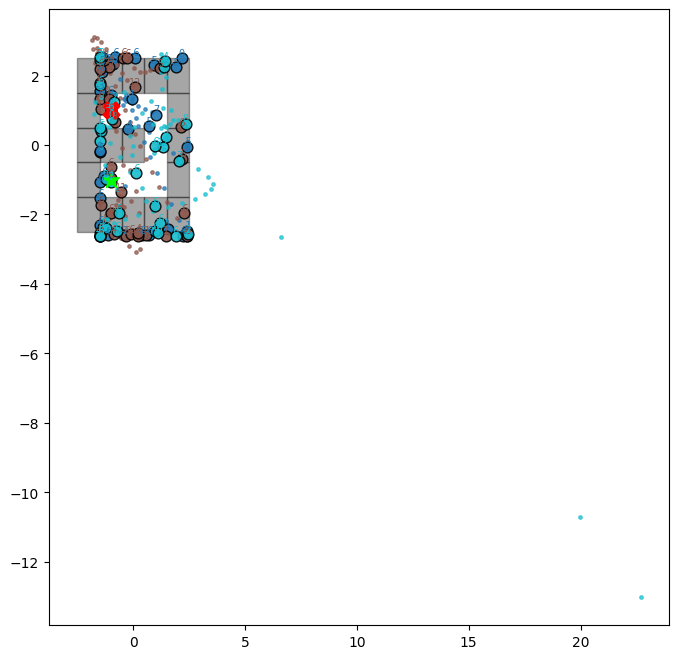

In [7]:
import matplotlib.pyplot as plt
num_samples = 3   # number of trajectories to sample
#WHEN USING THE 48 HORIZON, REMEMBER TO CHANGE HORIZON IN CODE...?
fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.tab10(np.linspace(0, 1, num_samples))


planner = DiffuserPlanner(eqnet, diffusion, dataset, device=device)

current = np.array([-1, -1, 0.88507522, 4.78210334])
goal = np.array([-1, 1])

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        TotalTimeSkipPenalty(reward_scale=0.00),
        CurvaturePenalty(reward_scale=0.00), #was 0.1
        LogSkipReward(reward_scale=0.00)
    ]
)

for k in range(num_samples):
    print(f"\n=== Trajectory {k+1}/{num_samples} ===")

    traj = planner.plan_and_reconstruct(
        current,
        goal,
        reward_fn=reward_fn,
        horizon=32,
        guidance_scale=1.0,
        condition_on_start=True,
        condition_on_goal=True,
        conditioning_schedule="constant",
        conditioning_strength=0.9,
        spline_func=expand_spline_from_skip_list,
    )

    pos_dense   = traj["pos_dense"]
    coarse_pos  = traj["coarse_pos"]
    coarse_skip = traj["coarse_skip"]

    color = colors[k]

    # -----------------------------------------------------------
    # Dense trajectory (THE ONLY LABEL)
    # -----------------------------------------------------------
    """
    ax.plot(
        pos_dense[:, 0],
        pos_dense[:, 1],
        linewidth=2,
        color=color,
        alpha=0.9,
        label=f"Trajectory {k+1}"
    )"""
    ax.scatter(
        pos_dense[:, 0],
        pos_dense[:, 1],
        s=6,                 # small dots
        color=color,
        alpha=0.7,
        label=f"Trajectory {k+1}"
    )

    # -----------------------------------------------------------
    # Coarse waypoints (NO LEGEND LABEL)
    # -----------------------------------------------------------
    
    ax.scatter(
        coarse_pos[:, 0],
        coarse_pos[:, 1],
        s=60,
        c=[color],
        edgecolors="k",
        alpha=0.9,
        label=None     # <--- IMPORTANT: no extra legend entry
    )
    

    # Skip labels
    for i, (x, y) in enumerate(coarse_pos):
        ax.text(x, y, f"{int(coarse_skip[i])}",
                fontsize=7, ha="center", va="bottom", color=color)
        
    coarse_skip = traj["coarse_skip"]  # (H,)

    total_steps = coarse_skip.sum()
    mean_skip  = coarse_skip.mean()
    max_skip   = coarse_skip.max()

    print(
        f"Trajectory {k+1}: "
        f"Σ skips = {total_steps:.1f}, "
        f"mean skip = {mean_skip:.2f}, "
        f"max skip = {max_skip:.1f}"
    )

# -----------------------------------------------------------
# Start + Goal
# -----------------------------------------------------------
ax.scatter(current[0], current[1], s=150, marker="*", color="lime", label="Start")
ax.scatter(goal[0],    goal[1],    s=150, marker="X", color="red",  label="Goal")

# -----------------------------------------------------------
# Maze walls (mj_model already available)
# -----------------------------------------------------------
for geom_id in range(mj_model.ngeom):
    name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)

    # Only render maze walls (named "block", like in PointMaze)
    if name is None or ("block" not in name):
        continue

    pos = mj_model.geom_pos[geom_id]      # (x, y, z) center
    size = mj_model.geom_size[geom_id]    # half-sizes (hx, hy, hz)

    cx, cy = pos[:2]
    hx, hy = size[:2]

    rect = Rectangle(
        (cx - hx, cy - hy),
        2 * hx, 2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)



=== Trajectory 1/5 ===
✗ Collision at dense index 17

=== Trajectory 2/5 ===
✗ Collision at dense index 3

=== Trajectory 3/5 ===
✗ Collision at dense index 22

=== Trajectory 4/5 ===
✗ Collision at dense index 19

=== Trajectory 5/5 ===
✗ Collision at dense index 7


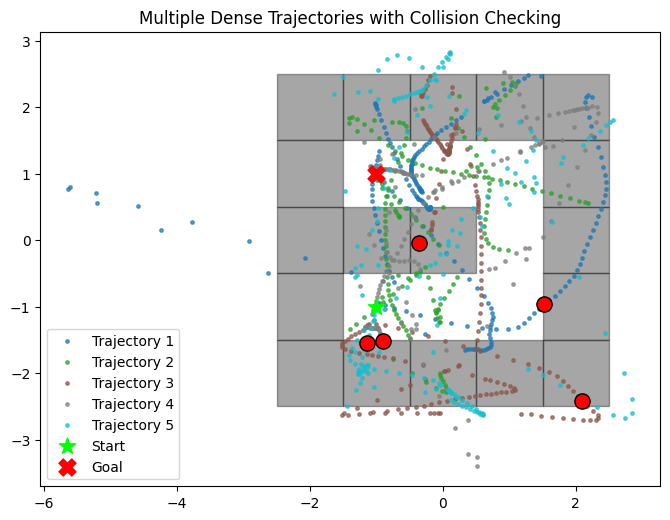

In [14]:
# -----------------------------------------------------------
# Multi-sample collision-aware visualization
# -----------------------------------------------------------

wall_rects = extract_wall_rects("D4RL/pointmaze/umaze-v2")

num_samples = 5
colors = plt.cm.tab10(np.linspace(0, 1, num_samples))

fig, ax = plt.subplots(figsize=(8, 8))

for k in range(num_samples):
    print(f"\n=== Trajectory {k+1}/{num_samples} ===")

    traj = planner.plan_and_reconstruct(
        current,
        goal,
        reward_fn=reward_fn,
        horizon=32,
        guidance_scale=1.0,
        condition_on_start=True,
        condition_on_goal=True,
        conditioning_schedule="constant",
        conditioning_strength=0.9,
        spline_func=expand_spline_from_skip_list,
    )

    pos_dense = traj["pos_dense"]
    color = colors[k]

    # -------------------------------------------------------
    # Plot dense trajectory (points only)
    # -------------------------------------------------------
    ax.scatter(
        pos_dense[:, 0],
        pos_dense[:, 1],
        s=6,
        color=color,
        alpha=0.7,
        label=f"Trajectory {k+1}"
    )

    # -------------------------------------------------------
    # Collision check
    # -------------------------------------------------------
    feasible, coll_idx = verify_trajectory_dense(pos_dense, wall_rects)

    if feasible:
        print("✓ Collision-free")
    else:
        print(f"✗ Collision at dense index {coll_idx}")

        cx, cy = pos_dense[coll_idx]
        ax.scatter(
            cx, cy,
            s=120,
            color="red",
            edgecolors="k",
            zorder=10
        )

# -----------------------------------------------------------
# Start + Goal
# -----------------------------------------------------------
ax.scatter(
    current[0], current[1],
    s=150, marker="*", color="lime", label="Start"
)
ax.scatter(
    goal[0], goal[1],
    s=150, marker="X", color="red", label="Goal"
)

# -----------------------------------------------------------
# Maze walls
# -----------------------------------------------------------
for geom_id in range(mj_model.ngeom):
    name = mujoco.mj_id2name(
        mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id
    )
    if name is None or "block" not in name:
        continue

    pos = mj_model.geom_pos[geom_id]
    size = mj_model.geom_size[geom_id]

    cx, cy = pos[:2]
    hx, hy = size[:2]

    rect = Rectangle(
        (cx - hx, cy - hy),
        2 * hx, 2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)

# -----------------------------------------------------------
# Formatting
# -----------------------------------------------------------
ax.set_aspect("equal")
ax.set_title("Multiple Dense Trajectories with Collision Checking")
ax.legend()
plt.show()


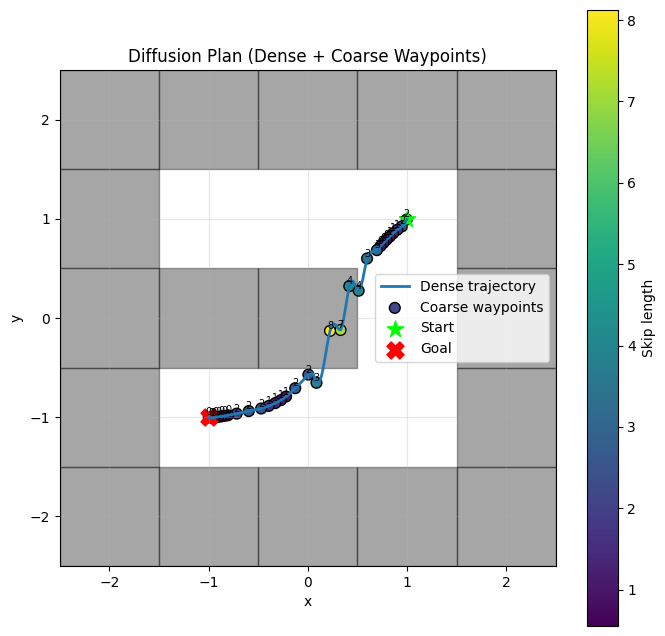